In [1]:
import numpy as np
import pickle
import os
import sys
import sled_deconvolution
import sled_summarize_anms
import sled_summarize_anms_traceAnalysis
import sled_summarize_anms_traceAnalysis_figs
import sled_summarize_anms_ROI_clustering
import sled_summarize_anms_trial_align
import sled_general_tools
import sled_stat_tools
import sled_image_tools
import sled_trace_tools
import sled_ROI_tools
import sled_dask_mgmt
import sled_tracker_tools
import copy
import glob
import cv2
from matplotlib.colors import ListedColormap
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import importlib
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime, date
from dask.distributed import Client, progress,wait
import dask.array as da
import dask
import time
import timeit
import matplotlib
import matplotlib as mpl
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

import ttracking as tt
import jsimg as jsi
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
warnings.simplefilter('ignore', RuntimeWarning)

In [2]:
#sled initialization
import sled_general_tools
sled_controls, tracker_info, SLURM_tracker_info, error_tracking = sled_general_tools.sled_init()
sled_controls, tracker_info, SLURM_tracker_info = sled_general_tools.where_am_I(sled_controls, tracker_info, SLURM_tracker_info)

|=====================================================================
|    Current Computer/Node:     bullwinkle
|    currentPlatform =          Linux
|    currentPlatformVersion =   #1 SMP PREEMPT_DYNAMIC Wed Jul 16 21:00:44 UTC 2025
|    currentPlatformMachine =   x86_64
|    currentPlatformProcessor = x86_64
|    Current TimeStamp =        27-Apr-2026 15:20:30
|    <<IMPORTANT>> Running on Linux
|=====================================================================
|    CPUs/Threads Available: 256
|    CPU Usage:              0.3%
|    Avaiable RAM:           1229.7 GiB 75.8% FREE
|    Resident Set Size:      0.37 GiB  (psutil.Process())
|    Virtual Memory Size:    7.33 GiB 
|---------------------------------------------------------------
|    NO GPUs Available!
|=====================================================================
|=====================================================================
|    SLED-Specific PATHS and Environmental Varialbles (and current keys in sled_

# <font size="5">Just load activity stats

In [3]:
activityStats_dir = '/export/disk1/pooledData/Calcium/fullCombinedData_activityStats'
activityStats_fileSuffix = '_fullCombinedData_activityStats.p'
ROI_types = {'dendrites': {1: 'L1_Dend', -1: 'L1_Axon', 0: 'L1_BadROI'}, 'somas': {1: 'L5_Soma', -1: 'L5_Dend', 0: 'L5_BadROI'}}
anm_list = ['B00002121749', 'B00002121774', 'B00002121777', 'B00002213772', 'B00002213773', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213909', 'B00002213920', 'B00002213921', 'B00002213932', 'B00002213943', 'B00002213944', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213998', 'B00002213999', 'B00002214001']

activityStats, activityAnalysis = sled_summarize_anms_traceAnalysis.quick_activity_analysis_loading(anm_list,ROI_types,activityStats_dir,activityStats_fileSuffix,True)

---------------------------------------------
Animal 1/22: B00002121749
Loading: B00002121749_fullCombinedData_activityStats.p...Finished!
Adding: Skipping dendrites...somas Activity Stats...sess0...sess1...sess2...sess3...sess4...Finished!
---------------------------------------------
Animal 2/22: B00002121774
Loading: B00002121774_fullCombinedData_activityStats.p...Finished!
Adding: dendrites Activity Stats...sess0...sess1...sess2...sess3...somas Activity Stats...sess0...sess1...sess2...sess3...sess4...Finished!
---------------------------------------------
Animal 3/22: B00002121777
Loading: B00002121777_fullCombinedData_activityStats.p...Finished!
Adding: dendrites Activity Stats...sess0...sess1...sess2...sess3...sess4...somas Activity Stats...sess0...sess1...sess2...sess3...sess4...Finished!
---------------------------------------------
Animal 4/22: B00002213772
Loading: B00002213772_fullCombinedData_activityStats.p...Finished!
Adding: dendrites Activity Stats...sess0...sess1...ses

# <font size="5">Just Load summaryInfo

In [4]:
if 'Windows' in sled_controls['currentPlatform']:
    combDataDir = 'K:/pooledData/Calcium/fullCombinedData_decon_ZN_events/'
    summaryDataDir = 'K:/pooledData/Calcium/summaryInfo/'
    combSaveDir = 'K:/pooledData/Calcium/summaryInfo/models/'
    combScratchDir = 'c:/scratch/'
    figSaveDir = 'K:/pooledData/Calcium/summaryInfo/figs/'
    safe_unpickle = True
    safe_pickle = True
elif 'bull' in sled_controls['currentHostName']:
    sled_controls['DATA_PARENT_PATH'] = "/export/disk1/"
    combDataDir = os.path.join(sled_controls['DATA_PARENT_PATH'],'pooledData','Calcium','fullCombinedData_decon_ZN_events')
    summaryDataDir = os.path.join(sled_controls['DATA_PARENT_PATH'],'pooledData','Calcium','summaryInfo')
    combSaveDir = os.path.join(sled_controls['DATA_PARENT_PATH'],'pooledData','Calcium','summaryInfo','models')
    combScratchDir = os.path.join(sled_controls['DATA_PARENT_PATH'],'scratch')
    figSaveDir = os.path.join(sled_controls['DATA_PARENT_PATH'],'pooledData','Calcium','summaryInfo','figs')
    safe_unpickle = False
    safe_pickle = True
else:
    combDataDir = '/home/akerlin/shared/pooledData/Zach/fullCombinedData_decon_ZN_events/'
    summaryDataDir = '/home/akerlin/shared/pooledData/Zach/summaryInfo/'
    combSaveDir = '/scratch.global/KerlinLab/summaryInfo/models/'
    combScratchDir = '/scratch.local/'
    figSaveDir = '/scratch.global/KerlinLab/summaryInfo/figs/'
    safe_unpickle = True
    safe_pickle = True

fileType = '_fullCombinedData_decon.p'
anm_search_ID = 'B000'
loadAnms=[] #Empty loads all
scaleRawDataMethod = None
importAllTraces = True
goodROI_scores = [1] #1 = Good 0 = unsure, -1 = opposite i.e. axon in dend or dend in soma
summaryInfo = sled_general_tools.safe_unpickler(summaryDataDir,"summaryInfo",safe_unpickle)
# variables_total_size=sled_general_tools.profile_variable_sizes(locals().items(),1.1e8)
ROI_types, goodROI_scores, traceKeys = jsi.get_general_params()
sled_general_tools.memory_cleanup(True)

savePath: /export/disk1/pooledData/Calcium/summaryInfo
File: summaryInfo.pkl
FileSize:      38.51 GB (35.87 GiB)
Last Modified: 2026-02-03 15:29:54.994220
Loading summaryInfo.pkl from /export/disk1/pooledData/Calcium/summaryInfo...Finished!
Loading Took a total of : 1.099 min
traceKeys for fullCombinedData:
   'consensus_NMFtc_mask' = boolean of good frames as determined by NMF reconstruction
   'consensus_NMFtc_raw' = NMF trace 'meanVals' imported from pooledData and shifted by the ROI median to correct for NMF offsets
   'consensus_NMFtc_baseline' = the running baseline values of consensus_NMFtc_raw, currently a running percentile
   'consensus_NMFtc_dff' = DFF using the baseline trace, and is currently updated at fullCombined stage to overwrite the imported values
                           <IMPORTANT> initially this is imported from pooledData using the 'DeltaFF0_corr' key
   'consensus_NMFtc_dff_bc' = Additional baseline correction applied to the DFF trace
   'consensus_NMFtc_dff_

# <font size="5">Paper Figure Panels

In [51]:
priority_ROI_types = ['L1_Dend','L5_Soma']
priority_ROI_type_labels = {}
priority_ROI_type_labels['L1_Dend'] = 'Tuft'
priority_ROI_type_labels['L5_Soma'] = 'Somata'

summaryInfo['ROI_type_colors']['dendrites'][1] = (0,0.75,0.75)
summaryInfo['ROI_type_colors']['somas'][1] = (0.75,0,0.75)

# <font size="5">Decon Impulse Paper Figure Panels

Exporting Decon_Impulse_Summary.pdf...


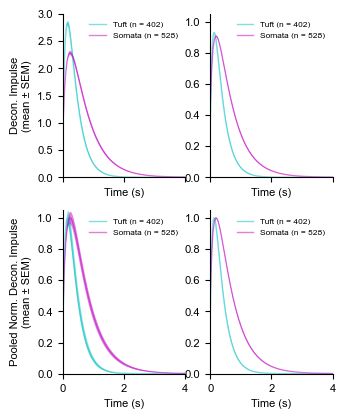

In [52]:
fontsize = 8
tickFontSize = 8
figsize=(3,4)
panel2save = [1,0]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)

figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"
aa = 'NMF_dffbc_dynSN_eventSplit_sp_event_thresh'

figName = 'Decon_Impulse_Summary.pdf'
importlib.reload(sled_summarize_anms_traceAnalysis_figs)
figData = sled_summarize_anms_traceAnalysis_figs.decon_impulse_fig(activityAnalysis,summaryInfo,aa,priority_ROI_types,priority_ROI_type_labels,fontsize,tickFontSize,figName,figSaveDir,figsize,panel2save,gridspec_kw)

# <font size="5">By Day Paper Figure Panels

In [53]:
#By Day Shared Fig Params
xlims = [-5.3,5.3]
fontsize = 8
tickFontSize = 8
figsize=(4.5,3)
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.2
)


Exporting Mean_spFreq_byDay.pdf...
[-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


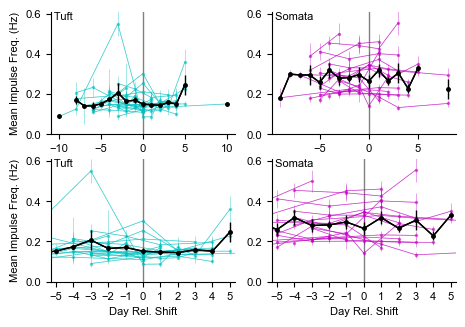

In [55]:
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"

figName = 'Mean_spFreq_byDay.pdf'
aa = 'SP_Events'
eventProperty = 'activity_freq_Hz'
ylabel = 'Mean Impulse Freq. (Hz)'
error = 'sem'
ykey = 'mean'
ylims = [0, 0.61]
importlib.reload(sled_summarize_anms_traceAnalysis_figs)
figData = sled_summarize_anms_traceAnalysis_figs.plot_stats_by_day(activityStats,summaryInfo,aa,eventProperty,priority_ROI_types,priority_ROI_type_labels,ylims,ylabel,ykey,error,xlims,fontsize,tickFontSize,figName,figSaveDir,figsize,gridspec_kw)

Exporting Mean_decon_noise_byDay.pdf...
[-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


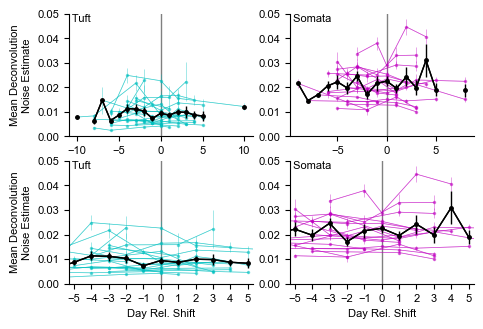

In [56]:
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"

figName = 'Mean_decon_noise_byDay.pdf'
aa = 'SP_Events'
eventProperty = 'decon_sn'
ylabel = 'Mean Deconvolution\nNoise Estimate'
error = 'sem'
ykey = 'mean'
ylims = [0, 0.05]
importlib.reload(sled_summarize_anms_traceAnalysis_figs)
figData = sled_summarize_anms_traceAnalysis_figs.plot_stats_by_day(activityStats,summaryInfo,aa,eventProperty,priority_ROI_types,priority_ROI_type_labels,ylims,ylabel,ykey,error,xlims,fontsize,tickFontSize,figName,figSaveDir,figsize,gridspec_kw)

# <font size="5">Histogram Paper Figure Panels

In [50]:
#Histogram Shared Fig Params
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"

additional_stats = {}
additional_stats['med'] = {}
additional_stats['med']['data'] = 'med'
additional_stats['med']['label'] = 'Median'
additional_stats['med']['ls'] = ':'
additional_stats['med']['lw'] = 1
additional_stats['med']['alpha'] = 1
fontsize = 8
tickfontsize = 8
figsize = (2,2)


Exporting NMF_dffbc_dynSN_eventSplit_sp_event_thresh_allROI_allSess_decon_t_rise_s_mean_linear_pdf.pdf...
L1 Apical Dend. Median 0.1389344036579132
L5 PT Soma Median 0.20446868240833282
Testing significance of data set 1 (n = 402) vs data set 2 (n = 528)
Kolmogorov–Smirnov test statistic: 0.403 p-value: 0.0
Wilcoxon rank sum test statistic: -10.3 p-value: 0.0


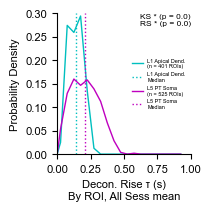

In [57]:
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"

aa = 'NMF_dffbc_dynSN_eventSplit_sp_event_thresh'
poolMethod = 'allROI_allSess'
eventProperty = 'decon_t_rise_s'
xlabel = 'Decon. Rise τ (s)'
xscale = 'linear'
xlim = [0,1]
ylim = [0,0.3]
eventProperty_stat = 'mean'
plot_hist = 'pdf'
histLabel = 'Probability Density'
importlib.reload(sled_summarize_anms_traceAnalysis_figs)
figData = sled_summarize_anms_traceAnalysis_figs.export_eventStatHist(summaryInfo,activityStats,activityAnalysis,aa,figSaveDir,\
                                                                      priority_ROI_types,priority_ROI_type_labels,summaryInfo['ROI_type_colors'],\
                                                                      poolMethod,eventProperty,xscale,xlabel,xlim,ylim,eventProperty_stat,plot_hist,histLabel,additional_stats,fontsize,tickFontSize,figsize)

Exporting NMF_dffbc_dynSN_eventSplit_sp_event_thresh_allROI_allSess_decon_t_decay_s_mean_linear_pdf.pdf...
L1 Apical Dend. Median 0.291293740272522
L5 PT Soma Median 0.4929197430610657
Testing significance of data set 1 (n = 402) vs data set 2 (n = 528)
Kolmogorov–Smirnov test statistic: 0.612 p-value: 0.0
Wilcoxon rank sum test statistic: -20.093 p-value: 0.0


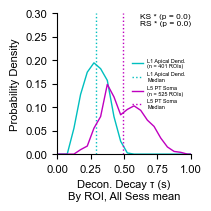

In [59]:
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig2"

aa = 'NMF_dffbc_dynSN_eventSplit_sp_event_thresh'
poolMethod = 'allROI_allSess'
eventProperty = 'decon_t_decay_s'
xlabel = 'Decon. Decay τ (s)'
xscale = 'linear'
xlim = [0,1]
ylim = [0,0.3]
eventProperty_stat = 'mean'
plot_hist = 'pdf'
histLabel = 'Probability Density'
importlib.reload(sled_summarize_anms_traceAnalysis_figs)
figData = sled_summarize_anms_traceAnalysis_figs.export_eventStatHist(summaryInfo,activityStats,activityAnalysis,aa,figSaveDir,\
                                                                      priority_ROI_types,priority_ROI_type_labels,summaryInfo['ROI_type_colors'],\
                                                                      poolMethod,eventProperty,xscale,xlabel,xlim,ylim,eventProperty_stat,plot_hist,histLabel,additional_stats,fontsize,tickFontSize,figsize)